In [2]:
import os
import io
from io import BytesIO
import gzip
import json
import pickle
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from dotenv import load_dotenv
from transformers import EsmForMaskedLM, EsmTokenizer
from peft import LoraConfig, get_peft_model
from google.cloud import storage

from scipy.stats import wilcoxon

warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

/opt/anaconda3/envs/MachLearn/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.stats import gaussian_kde
/opt/anaconda3/envs/MachLearn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
base_sp_df = pd.read_csv("/Users/johnhutchens/Desktop/Practicum/Data/Spearman_Data/base_spearman.csv.gz", index_col=0)

In [7]:
base_sp_df.shape

(522, 3)

In [6]:
base_sp_df.head()

,domain_id,ESM2_spearman,PG2_spearman
0,Q9Y6N9_PF00595_207,0.378841,0.497253
1,P20936_PF00018_281,0.422455,0.313600
2,Q86VP1_PF18112_729,0.299746,0.197311
3,P22681_PF00627_854,0.235321,0.352885
4,Q9P0J7_PF05605_76,0.303563,0.437686


In [8]:
base_sp_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 522 entries, 0 to 521
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   domain_id      522 non-null    object 
 1   ESM2_spearman  522 non-null    float64
 2   PG2_spearman   522 non-null    float64
dtypes: float64(2), object(1)
memory usage: 16.3+ KB


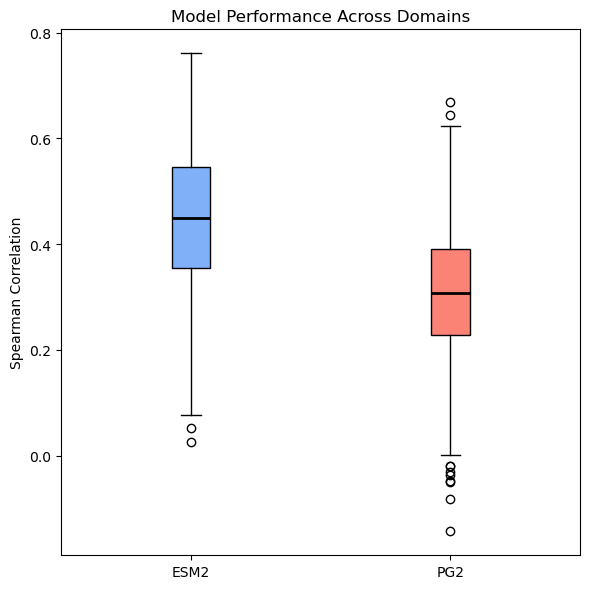

In [9]:
plot_df = base_sp_df.melt(
    id_vars="domain_id",
    value_vars=["ESM2_spearman", "PG2_spearman"],
    var_name="Model",
    value_name="Spearman"
)

fig, ax = plt.subplots(figsize=(6, 6))

bp = ax.boxplot(
    [
        plot_df.loc[plot_df["Model"] == "ESM2_spearman", "Spearman"],
        plot_df.loc[plot_df["Model"] == "PG2_spearman", "Spearman"],
    ],
    labels=["ESM2", "PG2"],
    patch_artist=True,
)

# Set box colors
colors = ["#80b0f8", "#fa8376"]  # blue, salmon

for box, color in zip(bp["boxes"], colors):
    box.set_facecolor(color)

# Make median lines black
for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(2)

ax.set_ylabel("Spearman Correlation")
ax.set_title("Model Performance Across Domains")

plt.tight_layout()
plt.show()

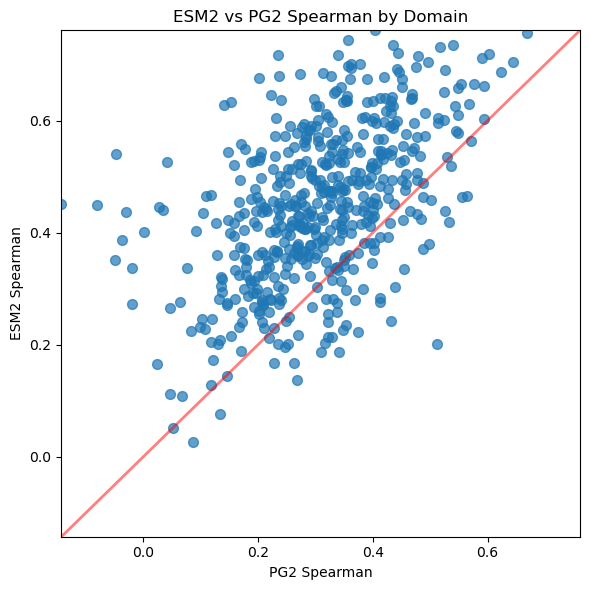

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    base_sp_df["PG2_spearman"],
    base_sp_df["ESM2_spearman"],
    alpha=0.7,
    s=50
)

# y = x reference line
lims = [
    min(base_sp_df["PG2_spearman"].min(), base_sp_df["ESM2_spearman"].min()),
    max(base_sp_df["PG2_spearman"].max(), base_sp_df["ESM2_spearman"].max())
]
ax.plot(lims, lims, alpha=0.5, color='red', linewidth=2)

ax.set_xlabel("PG2 Spearman")
ax.set_ylabel("ESM2 Spearman")
ax.set_title("ESM2 vs PG2 Spearman by Domain")

ax.set_xlim(lims)
ax.set_ylim(lims)

plt.tight_layout()
plt.show()

In [11]:
stat, p_value = wilcoxon(base_sp_df["ESM2_spearman"], base_sp_df["PG2_spearman"], alternative="greater")

print("Wilcoxon statistic:", stat)
print("p-value:", p_value)

Wilcoxon statistic: 128793.0
p-value: 2.511502536130298e-69


# Make a dataframe of all spearman data for ESM2 models

In [37]:
df_rho = pd.read_csv("/Users/johnhutchens/Desktop/Practicum/Data/Spearman_Data/PFAM_ALL_sp.csv.gz", index_col=0)

In [38]:
df_rho.shape

(522, 130)

In [39]:
df_rho.head()

,domain_id,pfam_id,base_rho,ft_ALL_rho,ft_PF00046_rho_n37,ft_PF00096_rho_n36,ft_PF00018_rho_n36,ft_PF00595_rho_n31,ft_PF00397_rho_n26,ft_PF00505_rho_n17,...,ft_PF00173_rho_n1,ft_PF05129_rho_n1,ft_PF18346_rho_n1,ft_PF01023_rho_n1,ft_PF01281_rho_n1,ft_PF18387_rho_n1,ft_PF07653_rho_n1,ft_PF13341_rho_n1,ft_PF09011_rho_n1,ft_PF05741_rho_n1
0,Q9Y6N9_PF00595_207,PF00595,0.378841,0.626113,0.407044,0.633606,0.378542,0.661614,0.379123,0.279686,...,0.387309,0.388459,0.383830,0.363722,0.375922,0.375464,0.371727,0.381273,0.378425,0.375639
1,P20936_PF00018_281,PF00018,0.422455,0.666934,0.340823,0.557630,0.424785,0.629427,0.423019,0.314266,...,0.420739,0.428673,0.424374,0.395134,0.422891,0.407285,0.444938,0.423156,0.420516,0.419652
2,Q86VP1_PF18112_729,PF18112,0.299746,0.531721,0.341736,0.415595,0.299951,0.413504,0.300894,0.153747,...,0.287383,0.313183,0.304743,0.312386,0.299976,0.322121,0.292600,0.297300,0.298335,0.302760
3,P22681_PF00627_854,PF00627,0.235321,0.457588,0.255850,0.410761,0.233061,0.423900,0.235649,0.197639,...,0.239267,0.247705,0.238320,0.221485,0.234028,0.229976,0.236586,0.235735,0.233723,0.234571
4,Q9P0J7_PF05605_76,PF05605,0.303563,0.520061,0.370226,0.368095,0.305097,0.503477,0.304922,0.216828,...,0.298062,0.326234,0.309549,0.328282,0.305513,0.305743,0.303561,0.305175,0.303796,0.308627
